In [2]:
import pickle
import os
import numpy as np
import xarray as xr

# -------------------------
# Load dataset
# -------------------------
ds = xr.open_dataset("sst.day.mean.2024.nc")

# Debug: Check for NaN values
print("Dataset dimensions:", ds.dims)
print("SST shape:", ds['sst'].shape)
print("Number of NaN values in first time step:", np.isnan(ds['sst'].isel(time=0).values).sum())
print("Total values in first time step:", ds['sst'].isel(time=0).values.size)
print("Percentage NaN:", np.isnan(ds['sst'].isel(time=0).values).sum() / ds['sst'].isel(time=0).values.size * 100)
print("SST min (ignoring NaN):", ds['sst'].min().values)
print("SST max (ignoring NaN):", ds['sst'].max().values)

# Create X, Y, U, T in XUYT form similar to main_gaussian_pulse

# X and Y are 2D meshgrids from lon and lat
lon_vals = ds['lon'].values
lat_vals = ds['lat'].values
X, Y = np.meshgrid(lon_vals, lat_vals)

# U is a list of 2D arrays for each time step
U = [ds['sst'].isel(time=i).values for i in range(len(ds['time']))]

# T is the time array
T = ds['time'].values

Dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 366, 'lat': 720, 'lon': 1440})
SST shape: (366, 720, 1440)
Number of NaN values in first time step: 345650
Total values in first time step: 1036800
Percentage NaN: 33.33815586419753
SST min (ignoring NaN): -1.8
SST max (ignoring NaN): 36.02


✓ SST evolution figure saved!


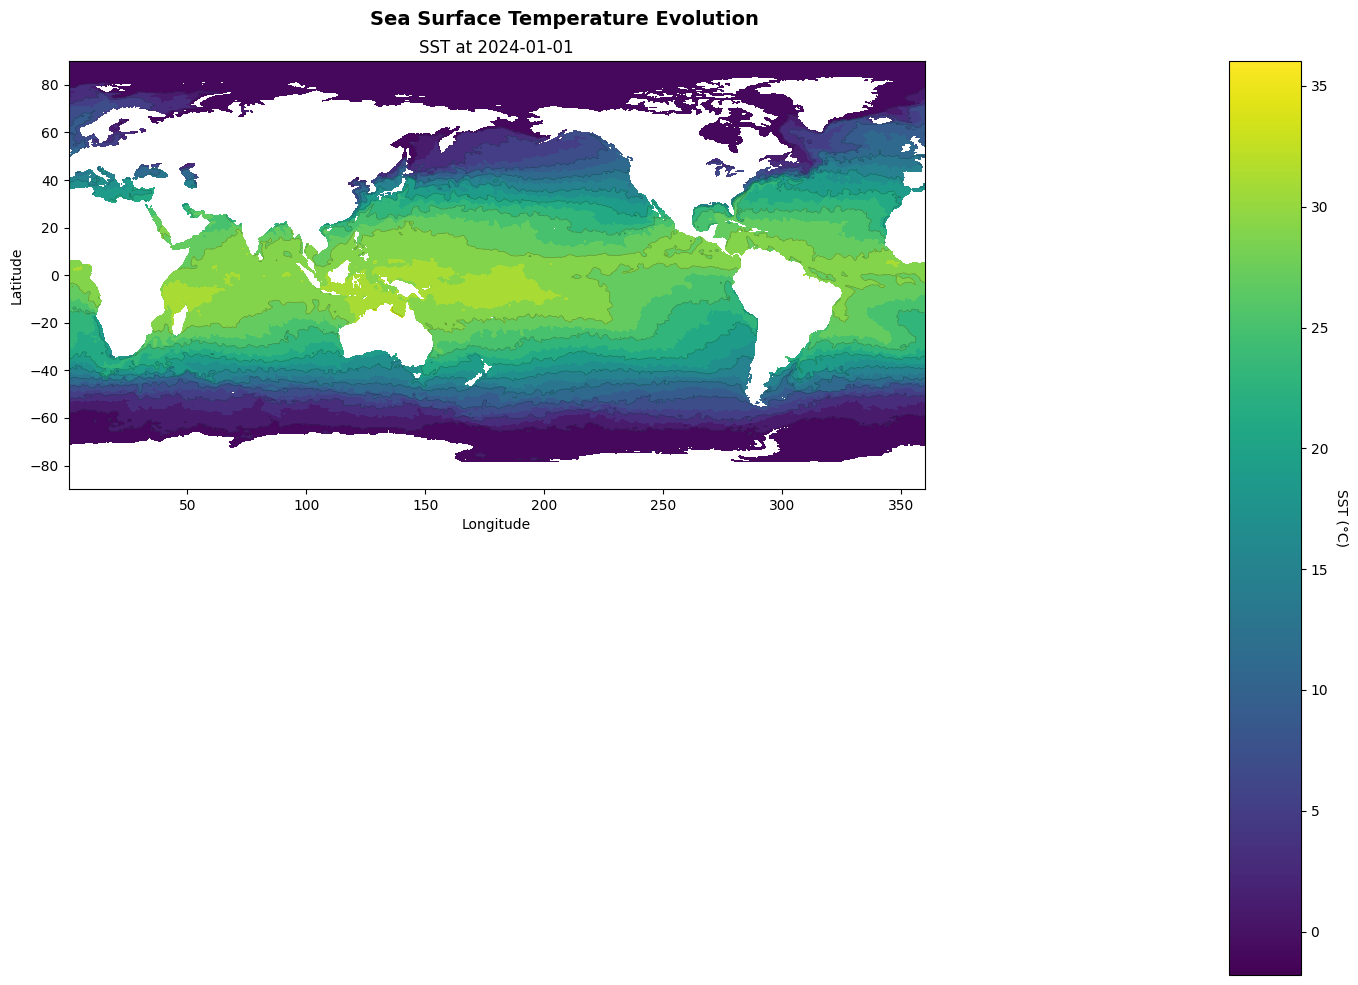

In [3]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def format_time(t):
    """Format datetime for title."""
    try:
        return np.datetime_as_string(np.array(t, dtype='datetime64[ns]'), unit='D')
    except:
        return str(t)

def create_visualisation(X, Y, snapshots, times, n_indices, vmin, vmax):
    """
    Create a grid of filled contour plots showing SST evolution
    with a unified colorbar spanning all plots
    
    Parameters:
    -----------
    X, Y : 2D arrays
        Spatial grid (longitude, latitude)
    snapshots : list of 2D arrays
        SST fields at different times
    times : 1D array
        Time values (datetime)
    n_indices : int
        Number of snapshots to display
    vmin, vmax : float
        Minimum and maximum values for colorbar scale
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    
    indices = np.linspace(0, len(snapshots) - 1, n_indices, dtype=int).tolist()
    ncols = int(np.ceil(len(indices) / 2))

    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, ncols + 1, width_ratios=[1]*ncols + [0.05], figure=fig)

    for i, idx in enumerate(indices):
        row = i // ncols
        col = i % ncols
        ax = fig.add_subplot(gs[row, col])
        
        # Create filled contour plot
        ax.contourf(X, Y, snapshots[idx], levels=20,
                    cmap='viridis', vmin=vmin, vmax=vmax)
        ax.contour(X, Y, snapshots[idx], levels=8,
                   colors='black', linewidths=0.5, alpha=0.3)
        ax.set_title(f'SST at {format_time(times[idx])}')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_aspect('equal')

    # Create colorbar with full range [vmin, vmax]
    cax = fig.add_subplot(gs[:, -1])
    sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=cax)
    cax.set_ylabel('SST (°C)', rotation=270, labelpad=15)

    fig.suptitle('Sea Surface Temperature Evolution',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('sst_evolution.png', dpi=150, bbox_inches='tight')
    print("✓ SST evolution figure saved!")
    
vmin = min([np.nanmin(s) for s in U])
vmax = max([np.nanmax(s) for s in U])
create_visualisation(X, Y, U, T, 1, vmin, vmax)

Cropped dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 366, 'lat': 80, 'lon': 260})
Cropped SST shape: (366, 80, 260)
Number of NaN values: 0
Total values: 7612800
Percentage NaN: 0.0
SST min (ignoring NaN): 17.869999
SST max (ignoring NaN): 31.83
Cropped data saved to c:\Users\darsh\Documents\fyp\myfyp\advection_diffusion\time_in_encoders_only\numerical_data_sst_smalltest.pkl
✓ SST evolution figure saved!


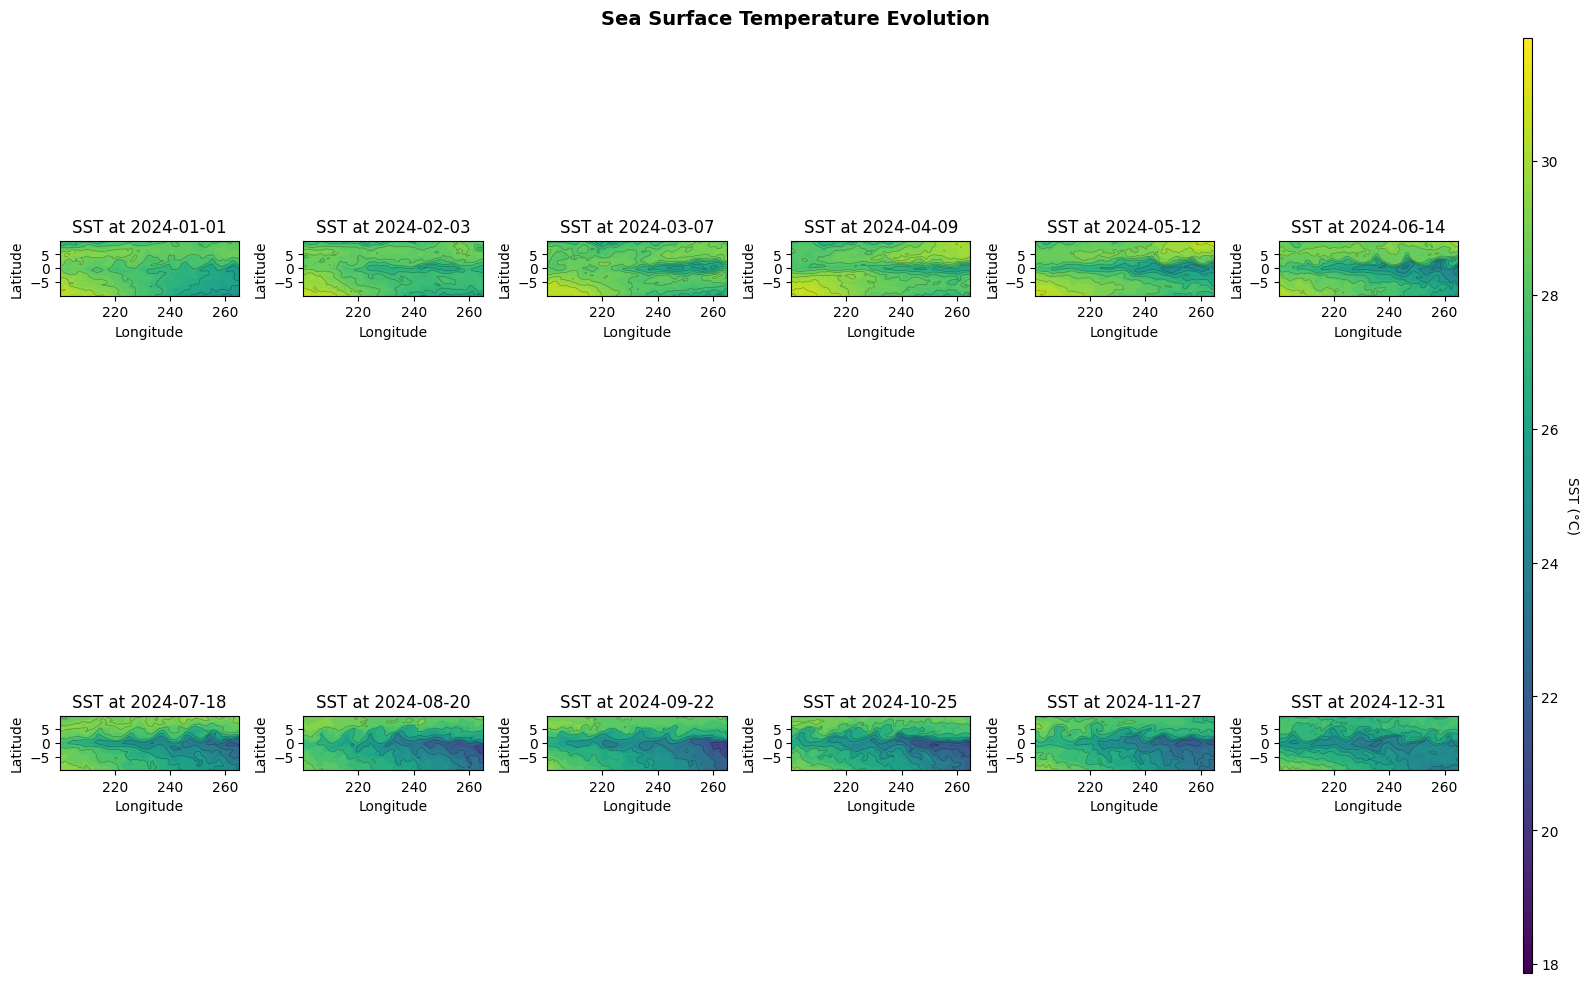

In [10]:
# -------------------------
# Crop the data to a specific region
# -------------------------
# lon_min, lon_max = 180, 270
# lat_min, lat_max = -60, 12
lon_min, lon_max = 200, 265
lat_min, lat_max = -10, 10
ds_cropped = ds.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

# Debug: Check cropped data
print("Cropped dataset dimensions:", ds_cropped.dims)
print("Cropped SST shape:", ds_cropped['sst'].shape)
print("Number of NaN values:", np.isnan(ds_cropped['sst'].values).sum())
print("Total values:", ds_cropped['sst'].values.size)
print("Percentage NaN:", np.isnan(ds_cropped['sst'].values).sum() / ds_cropped['sst'].values.size * 100)
print("SST min (ignoring NaN):", ds_cropped['sst'].min().values)
print("SST max (ignoring NaN):", ds_cropped['sst'].max().values)

# Create cropped X, Y, U, T
lon_vals_crop = ds_cropped['lon'].values
lat_vals_crop = ds_cropped['lat'].values
X_crop, Y_crop = np.meshgrid(lon_vals_crop, lat_vals_crop)
U_crop = [ds_cropped['sst'].isel(time=i).values for i in range(len(ds_cropped['time']))]
T_crop = ds_cropped['time'].values

# Save cropped data
save_path_crop = r"c:\Users\darsh\Documents\fyp\myfyp\advection_diffusion\time_in_encoders_only\numerical_data_sst_smalltest.pkl"
data_crop = {'X': X_crop, 'Y': Y_crop, 'U': U_crop, 'T': T_crop}
with open(save_path_crop, "wb") as f:
    pickle.dump(data_crop, f)
print(f"Cropped data saved to {save_path_crop}")

# Visualize cropped data
vmin_crop = min([np.nanmin(s) for s in U_crop])
vmax_crop = max([np.nanmax(s) for s in U_crop])
create_visualisation(X_crop, Y_crop, U_crop, T_crop, 12, vmin_crop, vmax_crop)

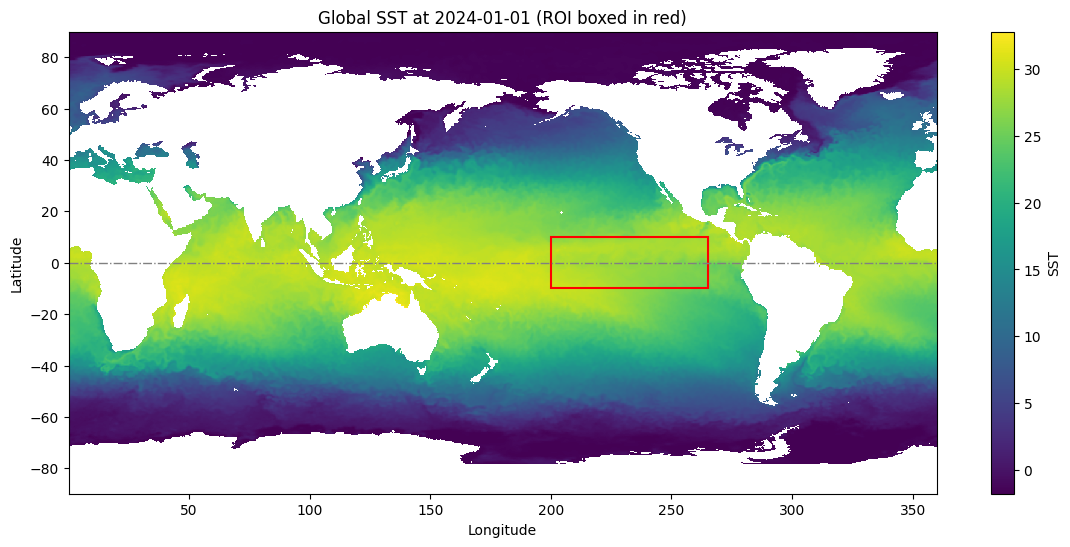

In [11]:
# -------------------------
# Visualise the *global* field at the initial timestep
# and draw a box showing the selected (lon, lat) region
# -------------------------
import matplotlib.patches as patches

# First timestep (global)
sst0 = ds['sst'].isel(time=0)
t0 = ds['time'].isel(time=0).values

fig, ax = plt.subplots(figsize=(14, 6))
# ds['lon'] and ds['lat'] are 1D coords; pcolormesh accepts this with 2D data
im = ax.pcolormesh(ds['lon'].values, ds['lat'].values, sst0.values, shading='auto')

# Region-of-interest box
roi = patches.Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    fill=False,
    linewidth=1.5,
    edgecolor='red'
)

ax.axhline(
    y=0,
    color='grey',
    linestyle='-.',
    linewidth=1,
    label='Equator'
)

ax.add_patch(roi)

ax.set_title(f"Global SST at {format_time(t0)} (ROI boxed in red)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(float(ds['lon'].min()), float(ds['lon'].max()))
ax.set_ylim(float(ds['lat'].min()), float(ds['lat'].max()))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("SST")

plt.show()


CROPPED REGION: lon [200, 265], lat [-10, 10]

Overall NaN Statistics (all 366 timesteps):
  Total NaN values across all timesteps: 0
  Total pixels: 7612800
  Percentage NaN: 0.00%

--- Analyzing First Timestep (t=0) ---
NaN in first timestep: 0 pixels
Number of distinct clusters: 0

--- NaN Distribution Across Time ---
  Timestep with most NaNs: t=0 (0 NaNs)
  Timestep with least NaNs: t=0 (0 NaNs)
  Average NaNs per timestep: 0


ValueError: Filled contours require at least 2 levels.

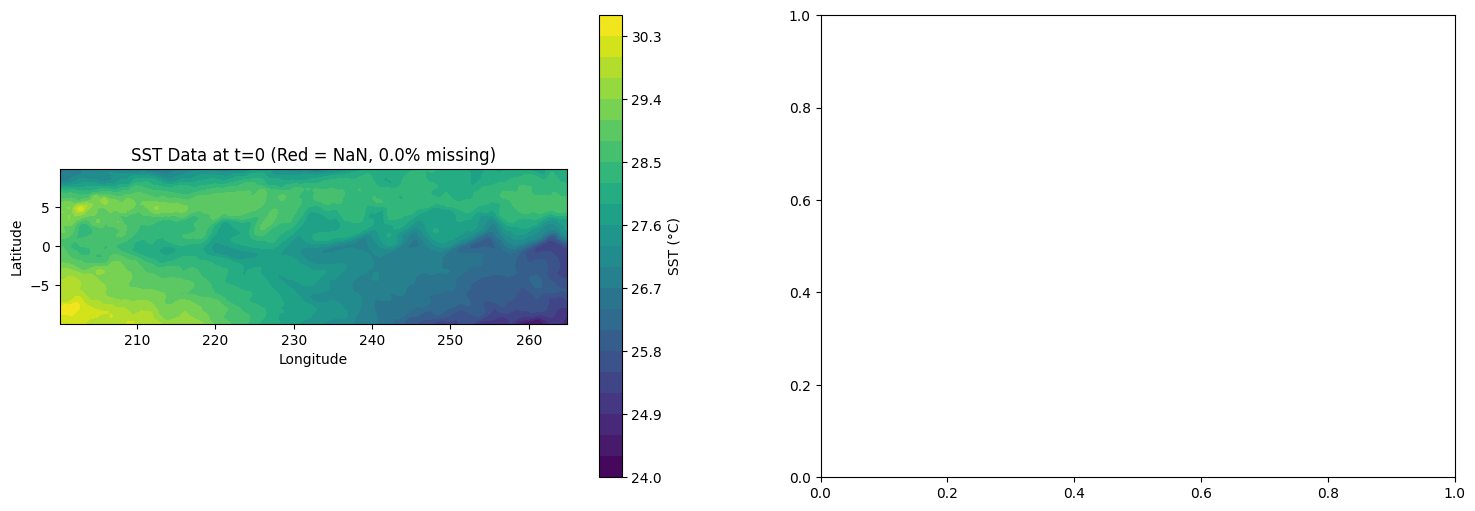

In [12]:
# -------------------------
# Analyze NaN clustering in cropped region (all timesteps)
# -------------------------
import matplotlib.pyplot as plt
from scipy import ndimage

print(f"CROPPED REGION: lon [{lon_min}, {lon_max}], lat [{lat_min}, {lat_max}]")
print(f"\nOverall NaN Statistics (all {len(U_crop)} timesteps):")
total_nan_all_times = sum(np.isnan(U_crop[t]).sum() for t in range(len(U_crop)))
total_pixels_all = U_crop[0].size * len(U_crop)
print(f"  Total NaN values across all timesteps: {total_nan_all_times}")
print(f"  Total pixels: {total_pixels_all}")
print(f"  Percentage NaN: {100 * total_nan_all_times / total_pixels_all:.2f}%")

# Analyze first timestep for clustering
print(f"\n--- Analyzing First Timestep (t=0) ---")
nan_mask_t0 = np.isnan(U_crop[0])
labeled_array_t0, num_features_t0 = ndimage.label(nan_mask_t0)

print(f"NaN in first timestep: {np.sum(nan_mask_t0)} pixels")
print(f"Number of distinct clusters: {num_features_t0}")

if num_features_t0 > 0:
    cluster_sizes = ndimage.sum(nan_mask_t0, labeled_array_t0, range(num_features_t0 + 1))
    cluster_sizes = cluster_sizes[cluster_sizes > 0]
    
    print(f"  Largest cluster: {int(np.max(cluster_sizes))} pixels")
    print(f"  Smallest cluster: {int(np.min(cluster_sizes))} pixels")
    print(f"  Mean cluster size: {int(np.mean(cluster_sizes)):.0f} pixels")
    
    # Find location of largest cluster
    largest_cluster_id = np.argmax(ndimage.sum(nan_mask_t0, labeled_array_t0, range(num_features_t0 + 1)))
    largest_cluster_mask = labeled_array_t0 == largest_cluster_id
    
    # Get lat/lon bounds of largest cluster
    y_indices, x_indices = np.where(largest_cluster_mask)
    if len(y_indices) > 0:
        y_min_idx, y_max_idx = y_indices.min(), y_indices.max()
        x_min_idx, x_max_idx = x_indices.min(), x_indices.max()
        
        lon_cluster_min = lon_vals_crop[x_min_idx]
        lon_cluster_max = lon_vals_crop[x_max_idx]
        lat_cluster_min = lat_vals_crop[y_min_idx]
        lat_cluster_max = lat_vals_crop[y_max_idx]
        
        print(f"\n  Largest cluster spans:")
        print(f"    Longitude: [{lon_cluster_min:.1f}, {lon_cluster_max:.1f}]")
        print(f"    Latitude: [{lat_cluster_min:.1f}, {lat_cluster_max:.1f}]")

# Check which timesteps have the most NaN values
nan_per_timestep = [np.isnan(U_crop[t]).sum() for t in range(len(U_crop))]
print(f"\n--- NaN Distribution Across Time ---")
print(f"  Timestep with most NaNs: t={np.argmax(nan_per_timestep)} ({max(nan_per_timestep)} NaNs)")
print(f"  Timestep with least NaNs: t={np.argmin(nan_per_timestep)} ({min(nan_per_timestep)} NaNs)")
print(f"  Average NaNs per timestep: {np.mean(nan_per_timestep):.0f}")

# Visualize NaN locations for first timestep
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: NaN mask overlaid on actual SST data (first timestep)
valid_data = np.where(~nan_mask_t0, U_crop[0], np.nan)
im1 = axes[0].contourf(X_crop, Y_crop, valid_data, levels=20, cmap='viridis')
axes[0].contourf(X_crop, Y_crop, nan_mask_t0.astype(float), levels=[0.5, 1.5], 
                 colors=['red'], alpha=0.5)
axes[0].set_title(f'SST Data at t=0 (Red = NaN, {100 * np.sum(nan_mask_t0) / nan_mask_t0.size:.1f}% missing)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('SST (°C)')

# Plot 2: Cluster labeling (first timestep)
im2 = axes[1].contourf(X_crop, Y_crop, labeled_array_t0, levels=np.arange(0, num_features_t0+1),
                       cmap='tab20')
axes[1].set_title(f'NaN Clusters at t=0 ({num_features_t0} clusters)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('nan_clustering_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved as 'nan_clustering_analysis.png'")
plt.show()

# Assessment
if num_features_t0 > 0:
    largest_cluster_pct = 100 * np.max(ndimage.sum(nan_mask_t0, labeled_array_t0, range(num_features_t0 + 1))) / np.sum(nan_mask_t0)
    if largest_cluster_pct > 80:
        print(f"\n→ Assessment: NaNs are HIGHLY CLUSTERED ({largest_cluster_pct:.1f}% in single region)")
    elif largest_cluster_pct > 50:
        print(f"\n→ Assessment: NaNs are MODERATELY CLUSTERED ({largest_cluster_pct:.1f}% in largest region)")
    else:
        print(f"\n→ Assessment: NaNs are SCATTERED across region ({largest_cluster_pct:.1f}% in largest region)")
